In [1]:
# !pip install sentence-transformers
from sentence_transformers import SentenceTransformer, util

In [2]:
# Initialize the model
NLPmodel = SentenceTransformer('./sentence-transformers_all-MiniLM-L6-v2') # SentenceTransformer('all-MiniLM-L6-v2')

## Use our data

In [3]:
# import other packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
param_name = 'directness' #'subtlety'

In [5]:
expt_type = 'subtlety/without_cover_story/'
rootfile_loc = f'../../data/text_responses/{expt_type}'

In [6]:
df =  pd.read_csv(f'{rootfile_loc}/data_triallevel_sorted.csv',index_col=[0])
# df =  pd.read_csv('../data/collected_data/data_triallevel_sorted.csv',index_col=[0])
df.head()

,subID,stimset_rows,subtlety,responses,movie,trial_num
0,15000,0,0,grey dot following black dot,07cdb9d7-6577-428d-9498-8a7243527554,0
6,15001,1,0,A grey dot appeared to chase or follow a black...,53613c0d-b07e-4b22-b6ec-56dda26edc8f,6
0,15002,2,0,the black dot seemed to be running away from t...,19c65966-3d88-4851-afe4-ae34c498748c,0
2,15003,3,0,Black dot was following the grey dot,c188e383-94d7-475e-9da5-6d1f0a1184bb,2
3,15004,6,0,Black moved from right to left chasing the grey,49e5ac90-6e7f-4243-9552-8c4c10545895,3


In [7]:
df.insert(3,'directness',0)
df['directness'] = [np.round((180-i)/180,2) for i in df['subtlety']]
df.head()

,subID,stimset_rows,subtlety,directness,responses,movie,trial_num
0,15000,0,0,1.0,grey dot following black dot,07cdb9d7-6577-428d-9498-8a7243527554,0
6,15001,1,0,1.0,A grey dot appeared to chase or follow a black...,53613c0d-b07e-4b22-b6ec-56dda26edc8f,6
0,15002,2,0,1.0,the black dot seemed to be running away from t...,19c65966-3d88-4851-afe4-ae34c498748c,0
2,15003,3,0,1.0,Black dot was following the grey dot,c188e383-94d7-475e-9da5-6d1f0a1184bb,2
3,15004,6,0,1.0,Black moved from right to left chasing the grey,49e5ac90-6e7f-4243-9552-8c4c10545895,3


## NLP algo

In [8]:
words_to_compare = df['responses'].to_list()
words_to_compare = [s.lower() for s in words_to_compare]
words_to_compare

['grey dot following black dot',
 'a grey dot appeared to chase or follow a black dot right and then up.',
 'the black dot seemed to be running away from the gray one',
 'black dot was following the grey dot',
 'black moved from right to left chasing the grey',
 'black dot was being chased by the grey one',
 'it seemed like the grey dot was trying to chase the black dot',
 'lighter dot is being pressured by dark one',
 'grey sot following black dot',
 'the black dot was following the grey dot in a beeline.',
 'black dot being chased by white dot',
 'again the black dot moved toward the grey dot which moved to get away from the black dot',
 'the grey dot approached the black dot and both curved in a downwards sweep to the bottom of the box',
 'the grey dot was chasing the black dot',
 'the grey dot was moving closer to the black dot, as they reached a distance, the dot did not move any closer but mimicked the moves of the other one ',
 'black chasseing dray dot',
 'the white dot is chas

In [9]:
excluded_words_list = ['dots','dot','around','dont know',"don't know",'black','grey','gray', 'color', 'colors','shape', 'shapes', 'one', 'ones','ball',\
    'balls','twice', '.', ';', ':', '-', ' the ', ' and ', ' a ', ' an ', ' is ', ' are ', ' and ', ' or ', 'between']

In [10]:
def skip_excluded_words(txt):
    txt = txt.lower()
    for words in excluded_words_list:
        txt = txt.replace(words,' ')
    return txt

skip_excluded_words('This is black.')

'this   '

In [12]:
words_to_compare[:5]

['grey dot following black dot',
 'a grey dot appeared to chase or follow a black dot right and then up.',
 'the black dot seemed to be running away from the gray one',
 'black dot was following the grey dot',
 'black moved from right to left chasing the grey']

In [13]:
# ref_words = ['follow','chase','wander','move','independent', 'moveInd']
ref_words = ['chasing','moveInd', 'chase_moveInd']

In [14]:
# Encode the reference phrase and the words to compare
similarity_all_1 = []
similarity_all_2= []

for ref_word in ref_words[:-1]:
    if ref_word == 'moveInd':
        print('here')
        reference_embedding = NLPmodel.encode('moving independently')
    else:
        reference_embedding = NLPmodel.encode(ref_word)

    data_embeddings = NLPmodel.encode(words_to_compare)

    # Compare and print similarities
    for embedding in data_embeddings:

        similarity = util.pytorch_cos_sim(reference_embedding, embedding) # similarity between ref word and each response

        if ref_word in ['chase','chasing']:
            similarity_all_1.append(similarity.item())

        if ref_word in ['moveInd', 'move independently','moving independently']:
            similarity_all_2.append(similarity.item())

df['similarity_chasing'] = similarity_all_1
df['similarity_moveInd'] = similarity_all_2
df['similarity_chase_moveInd'] = df['similarity_chasing'] - df['similarity_moveInd']

here


In [16]:
df.sort_values(by=['directness','subID'],inplace=True)
df

,subID,stimset_rows,subtlety,directness,responses,movie,trial_num,similarity_chasing,similarity_moveInd,similarity_chase_moveInd
3,15000,0,180,0.0,moving largely in line up and down,4bc5af99-ede5-49ec-a929-d4fc6fae9b43,3,0.248778,0.487897,-0.239118
1,15001,1,180,0.0,A grey dot and black dot appeared to move arou...,7bee52f4-919b-4633-b742-a0181f5f7f01,1,0.112495,0.184629,-0.072134
2,15002,2,180,0.0,they were both going in somewhat circular move...,802575f0-631d-4eeb-9e49-3b401b11b953,2,0.166011,0.313264,-0.147254
4,15003,3,180,0.0,both dots going around in random circles,00ccc21a-d63a-41eb-8d3b-a2315d7b0d3e,4,0.165211,0.109503,0.055709
5,15004,6,180,0.0,grey moved in circles black from top to bottom,4a6f7598-dc16-47d6-987e-a48c1f938428,5,0.085941,0.183450,-0.097510
...,...,...,...,...,...,...,...,...,...,...
1,15055,71,0,1.0,dots moving upwards- one following the other dot,72e764e1-0b34-4efd-96db-5df7934b2395,1,0.231920,0.276574,-0.044654
6,15056,65,0,1.0,they both moved toward the upper left side,9dfa52b0-9e95-49de-bddb-e53316f2b4ae,6,0.155239,0.347090,-0.191851
0,15057,68,0,1.0,The black dot was following the grey dot into ...,37b0c4a3-57d4-4b4a-9bf7-e4d2eb48cee6,0,0.215175,0.054075,0.161100
2,15058,73,0,1.0,the black dot began to follow the grey dot,c188e383-94d7-475e-9da5-6d1f0a1184bb,2,0.196973,0.055689,0.141284


In [17]:
rootfile_loc

'../../data/text_responses/subtlety/without_cover_story/'

In [18]:
df.to_csv(f'{rootfile_loc}/NLP_analyses/data_with_similarity_scores.csv')

# Figures

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=14) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

color_plots = 'tab:blue' # or tab:red

In [20]:
ref_words

['chasing', 'moveInd', 'chase_moveInd']

In [25]:
out_loc = '../../results/text_analysis/subtlety/no_cover_story/'

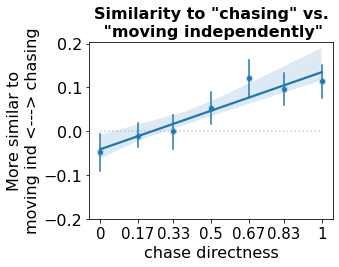

In [31]:
# nrows,ncols = 2,3
# fig,axs = plt.subplots(nrows = 2, ncols = 3, figsize = (12,6), sharey = False)
fig,ax = plt.subplots(nrows=1,ncols=1,figsize = (5,4))

word = 'chase_moveInd'
sns.lineplot(data=df.reset_index(),x = param_name,y = 'similarity_' + word,\
    ax=ax,marker = 'o', ls = 'None', color = color_plots, err_style='bars')
sns.regplot(data=df.groupby([param_name]).mean().reset_index(),x = param_name,y = 'similarity_' + word,\
    ax=ax,scatter_kws = {'marker':None}, color = color_plots)
ax.set_xticks(np.unique(df[param_name]),[str(np.round(i)).split('.')[0] if i in [0,1] else str(np.round(i,2)) for i in np.unique(df[param_name])],fontsize=15, ha='center')


ax.set_title(f'Similarity to "chasing" vs.'  '\n "moving independently"', fontweight = 'bold')
# ax.hlines(0,0,180,color = 'grey',ls = ':',alpha=.4)
ax.hlines(0,0,1,color = 'grey',ls = ':',alpha=.4)
ax.set_yticks([-.2,-.1,0,0.1,0.2])

ax.set_ylabel('More similar to\nmoving ind <---> chasing')
# ax.invert_xaxis()

ax.set_xlabel('chase directness')

plt.tight_layout()
plt.savefig(f'{out_loc}word_similarity.png',dpi=300,bbox_inches ='tight')

### Stat + plots

In [77]:
from pymer4.models import Lmer
from pymer4.stats import vif
from scipy.stats import zscore

In [80]:
ref_words

['chasing', 'moveInd', 'chase_moveInd']

In [81]:
model = Lmer(f'similarity_{ref_words[0]} ~ directness +  (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

Formula: similarity_chasing~directness+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 420	 Groups: {'movie': 84.0, 'subID': 60.0}

Log-likelihood: 405.251 	 AIC: -810.502

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.000  0.007
subID     (Intercept)  0.003  0.051
Residual               0.007  0.082

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.176,0.157,0.196,0.010,90.726,17.759,0.0,***
directness,0.072,0.048,0.096,0.012,57.624,5.868,0.0,***


In [82]:
model = Lmer(f'similarity_{ref_words[1]} ~ directness +  (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

boundary (singular) fit: see ?isSingular 

Formula: similarity_moveInd~directness+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 420	 Groups: {'movie': 84.0, 'subID': 60.0}

Log-likelihood: 295.140 	 AIC: -590.281

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.000  0.000
subID     (Intercept)  0.004  0.061
Residual               0.012  0.109

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.217,0.193,0.242,0.012,158.005,17.528,0.0,***
directness,-0.104,-0.135,-0.072,0.016,359.000,-6.500,0.0,***


In [84]:
model = Lmer(f'similarity_{ref_words[2]} ~ directness  +  (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

boundary (singular) fit: see ?isSingular 

Formula: similarity_chase_moveInd~directness+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 420	 Groups: {'movie': 84.0, 'subID': 60.0}

Log-likelihood: 222.686 	 AIC: -445.373

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.000  0.000
subID     (Intercept)  0.007  0.085
Residual               0.016  0.127

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),-0.041,-0.072,-0.011,0.016,135.120,-2.638,0.009,**
directness,0.176,0.139,0.212,0.019,358.999,9.435,0.000,***
